# Angle-Periodic HCurl/HDiv Motor ROM

This notebook renders the committed 8-pole, 24-physical-slot curved-machine validation. The parent machine model uses fourth-order geometry and a third-order planar A-formulation; 33 odd, endpoint-exclusive angle samples construct the Fourier ROM and the interlaced 33 angles remain held out.

The generalized current contract places physical phase currents first and HCurl Eddy Bubble, conductor-cycle, or positive-real SIBC/CLN states afterward. This benchmark deliberately uses phase ports only so that the angle law is tested independently of the already gated HCurl reduction. The torque law contains reluctance, permanent-magnet, motional, hysteresis, and scalar cogging-coenergy terms, all tied to the same discrete power balance.

In [1]:
from pathlib import Path
import json
import numpy as np

here = Path.cwd().resolve()
repo = next(path for path in (here, *here.parents) if (path / 'validation_test').is_dir())
result_path = repo / 'validation_test/electric_machine/validation_pmsm_angle_periodic_rom_summary.json'
result = json.loads(result_path.read_text(encoding='utf-8'))
assert result['passed']
result['geometry'], result['rom']

({'machine': '8-pole 24-physical-slot PMSM benchmark',
  'pm_model': 'smooth radial remanence fundamental',
  'mesh_elements': 4350,
  'mesh_vertices': 2238,
  'maxh_m': 0.004,
  'geometry_order': 4,
  'fes_order': 3,
  'maxwell_circle_radius_m': 0.0502,
  'maxwell_circle_points': 8191},
 {'angle_samples': 33,
  'held_out_angles': 33,
  'mechanical_period_rad': 1.5707963267948966,
  'generalized_current_order': ['A', 'B', 'C'],
  'current_operating_point_A': [5.0, -2.5, -2.5],
  'passive': True,
  'includes_cogging_coenergy': True})

In [2]:
metrics = result['metrics']
{
    'PM flux max relative error': metrics['pm_flux_max_relative_error'],
    'Maxwell vs ROM torque relative RMSE': metrics['maxwell_vs_rom_torque_relative_rmse'],
    'FEM virtual work vs ROM relative RMSE': metrics['fem_virtual_vs_rom_torque_relative_rmse'],
    'ROM derivative vs virtual work max abs (N m)': metrics['rom_derivative_vs_virtual_max_abs_Nm'],
    'Minimum inductance eigenvalue (H)': metrics['minimum_inductance_eigenvalue_H'],
}

{'PM flux max relative error': 1.6658182787186744e-15,
 'Maxwell vs ROM torque relative RMSE': 0.0019010256513739064,
 'FEM virtual work vs ROM relative RMSE': 3.971365049541934e-09,
 'ROM derivative vs virtual work max abs (N m)': 2.3139945515282534e-10,
 'Minimum inductance eigenvalue (H)': 0.13651598648357532}

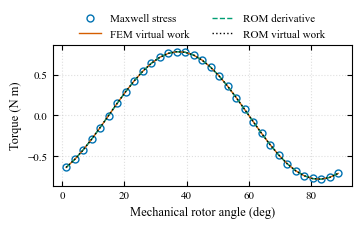

In [3]:
import matplotlib.pyplot as plt
from radia_mcp.figure import apply_lab_style, lab_savefig

rows = result['holdout_rows']
angle_deg = np.degrees([row['rotor_angle_rad'] for row in rows])
maxwell = [row['torque_maxwell_Nm'] for row in rows]
fem_virtual = [row['torque_fem_virtual_work_Nm'] for row in rows]
rom_derivative = [row['torque_rom_derivative_Nm'] for row in rows]
rom_virtual = [row['torque_rom_virtual_work_Nm'] for row in rows]

figsize = apply_lab_style('paper_single_column', aspect=0.62)
fig, ax = plt.subplots(figsize=figsize, constrained_layout=True)
ax.plot(angle_deg, maxwell, 'o', color='#0072B2', markerfacecolor='none', label='Maxwell stress')
ax.plot(angle_deg, fem_virtual, '-', color='#D55E00', label='FEM virtual work')
ax.plot(angle_deg, rom_derivative, '--', color='#009E73', label='ROM derivative')
ax.plot(angle_deg, rom_virtual, ':', color='#000000', label='ROM virtual work')
ax.set_xlabel('Mechanical rotor angle (deg)')
ax.set_ylabel('Torque (N m)')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.01), ncol=2, borderaxespad=0.0)
figure_base = repo / 'docs/electric_machine/angle_periodic_motor_rom_torque'
lab_savefig(fig, str(figure_base))
plt.show()

## Interpretation

The held-out flux result isolates the periodic interpolation and is essentially at floating-point precision. The remaining torque discrepancy is between a sampled air-gap stress integral and the coenergy routes; the direct FEM and ROM virtual-work values agree much more closely. The curved geometry is essential: the corresponding straight-segment trial produced percent-level stress error.

These values select neither p=6 nor 33 angles universally. Production selection is adaptive: increase parent order, retained response modes, and angle harmonics until corner/edge current, torque, loss, and passivity observables converge. A specific 3D machine still requires its own Cubit mesh, material history, end region, skew, temperature map, and positive-real SIBC realization.